In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler

from xgboost import XGBRegressor
from statsmodels.tsa.arima.model import ARIMA

import warnings
warnings.filterwarnings("ignore")

In [2]:
wind = pd.read_csv("/content/drive/MyDrive/Skripsi/Dataset/Wind Power/wind farm historical data.csv")
nwp = pd.read_csv("/content/drive/MyDrive/Skripsi/Dataset/Wind Power/NWP.csv")

In [3]:
wind['time'] = pd.to_datetime(wind['Date'], dayfirst=True)

wind = wind[['time','Speed','Direction','Energy']]
wind.columns = ['time','wind_speed','wind_dir','power']

In [4]:
nwp['time'] = pd.to_datetime(nwp['time'])

nwp = nwp[['time','mod','dir','temp','rh','mslp']]

nwp.columns = [
    'time',
    'nwp_speed',
    'nwp_dir',
    'temp',
    'humidity',
    'pressure'
]

In [5]:
nwp = nwp.set_index("time")

nwp = nwp.resample("10T").interpolate()

nwp = nwp.reset_index()

In [6]:
data = pd.merge(wind, nwp, on="time", how="inner")

data = data.sort_values("time")

In [7]:
data['hour'] = data['time'].dt.hour
data['month'] = data['time'].dt.month

data['hour_sin'] = np.sin(2*np.pi*data['hour']/24)
data['hour_cos'] = np.cos(2*np.pi*data['hour']/24)

In [8]:
def get_season(month):

    if month in [12,1,2]:
        return "winter"

    elif month in [3,4,5]:
        return "spring"

    elif month in [6,7,8]:
        return "summer"

    else:
        return "autumn"

data["season"] = data["month"].apply(get_season)

In [9]:
lags = [1,2,3,6,12,24]

for lag in lags:
    data[f'power_lag_{lag}'] = data['power'].shift(lag)

In [10]:
data['wind_speed_cube'] = data['wind_speed'] ** 3

In [11]:
windows = [3,6,12]

for w in windows:

    data[f'power_roll_mean_{w}'] = data['power'].rolling(w).mean()
    data[f'power_roll_std_{w}'] = data['power'].rolling(w).std()

In [12]:
data = data.dropna().reset_index(drop=True)

In [13]:
features = [
    'wind_speed',
    'pressure',
    'hour_sin',
    'hour_cos',
    'power_lag_1',
    'power_lag_2',
    'power_lag_3',
    'power_lag_6',
    'power_lag_12',
    'power_lag_24',
    'power_roll_mean_3',
    'power_roll_mean_6',
    'power_roll_std_3',
    'wind_speed_cube'
]

target = 'power'

In [14]:
train = data[data['season'] != "summer"]
test = data[data['season'] == "summer"]

X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

In [15]:
model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42
)

model.fit(X_train,y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.9, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

In [16]:
pred_xgb = model.predict(X_test)

In [17]:
arima = ARIMA(train['power'], order=(2,1,2))

arima_fit = arima.fit()

pred_arima = arima_fit.forecast(steps=len(test))

In [18]:
def evaluate(y_true,y_pred):

    rmse = np.sqrt(mean_squared_error(y_true,y_pred))
    mae = mean_absolute_error(y_true,y_pred)
    mse = mean_squared_error(y_true,y_pred)

    return rmse,mae,mse

In [19]:
rmse_xgb,mae_xgb,mse_xgb = evaluate(y_test,pred_xgb)
rmse_arima,mae_arima,mse_arima = evaluate(y_test,pred_arima)

print("XGBoost")
print("RMSE:",rmse_xgb)
print("MAE:",mae_xgb)

print("\nARIMA")
print("RMSE:",rmse_arima)
print("MAE:",mae_arima)

XGBoost
RMSE: 14.024579433863455
MAE: 8.254402182530939

ARIMA
RMSE: 537.3984041813936
MAE: 311.0925927939867


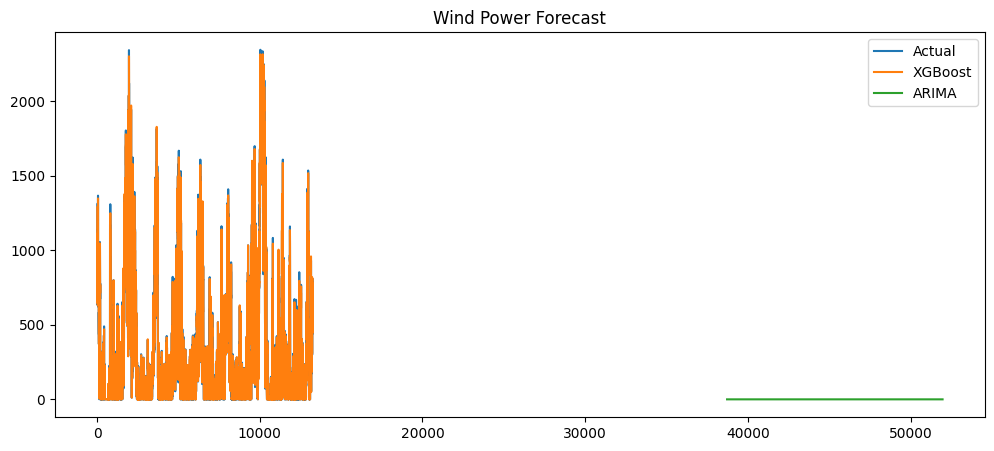

In [20]:
plt.figure(figsize=(12,5))

plt.plot(y_test.values,label="Actual")
plt.plot(pred_xgb,label="XGBoost")
plt.plot(pred_arima,label="ARIMA")

plt.legend()
plt.title("Wind Power Forecast")
plt.show()

In [21]:
importances = model.feature_importances_

feat_imp = pd.Series(importances,index=features)

feat_imp = feat_imp.sort_values(ascending=False)

print(feat_imp.head(10))

power_roll_mean_3    0.820655
power_roll_mean_6    0.075846
power_lag_1          0.073183
wind_speed           0.007573
power_lag_2          0.007146
power_roll_std_3     0.006877
wind_speed_cube      0.006669
power_lag_3          0.000725
pressure             0.000281
hour_cos             0.000220
dtype: float32
